# 01 — Data Exploration & Understanding

**Goal (spec §4):** Before building anything, spend time understanding what we are working with.

This notebook covers every investigation item listed in the spec:

1. Load the labels catalogue and audit the dataset
2. Class distribution check
3. Visualise triplets — one example per class
4. NaN / Inf audit across every downloaded stamp
5. Pixel-value distribution per class and per stamp-type
6. Image quality consistency (pixel-std proxy across nights / sky regions)
7. Temporal coverage — how are observations spread in MJD?
8. Artefact inspection — flag suspicious stamps
9. Summary & findings

> **Note:** Run `scripts/download_alerce.py` first to populate `data/raw/` and `data/labels.csv`.  
> All cells are self-contained; re-run any cell independently after a fresh download.

## 0 — Imports & paths

In [13]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from astropy.io import fits

# ── Paths ────────────────────────────────────────────────────────────────────
PROJECT_ROOT = Path('..').resolve()
LABELS_CSV   = PROJECT_ROOT / 'data' / 'labels.csv'
RAW_DIR      = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR      = PROJECT_ROOT / 'data' / 'processed'
# ── Plot aesthetics ───────────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.bbox': 'tight'})

# ── Colour map shared across the notebook ────────────────────────────────────
CLASS_COLOURS = {
    'SN':       '#e34a33',
    'AGN':      '#fdbb84',
    'VS':       '#2b8cbe',
    'asteroid': '#31a354',
    'bogus':    '#756bb1',
}

print('Imports OK')
print(f'Labels CSV : {LABELS_CSV}')
print(f'Raw stamps : {RAW_DIR}')

Imports OK
Labels CSV : /home/pranshav/Documents/PycharmProjects/transient-astronomy/data/labels.csv
Raw stamps : /home/pranshav/Documents/PycharmProjects/transient-astronomy/data/raw


## 1 — Load the labels catalogue

In [14]:
if not LABELS_CSV.exists():
    raise FileNotFoundError(
        f'labels.csv not found at {LABELS_CSV}.\n'
        'Run:  python scripts/download_alerce.py'
    )

df = pd.read_csv(LABELS_CSV)

# Convert MJD → approximate datetime for readability
# MJD 0 = 1858-11-17 00:00 UTC.  Offset to Unix epoch: 40587 days.
df['datetime'] = pd.to_datetime(
    (df['mjd'] - 40587.0) * 86400,   # seconds since Unix epoch
    unit='s', utc=True
)
df['date'] = df['datetime'].dt.date

# Binary real/bogus label (used throughout the project)
df['real_bogus'] = (df['class'] != 'bogus').astype(int)

print(f'Total rows : {len(df):,}')
print(f'Unique OIDs: {df["oid"].nunique():,}')
print(f'Classes    : {sorted(df["class"].unique())}')
print()
df.head()

Total rows : 131,270
Unique OIDs: 18,682
Classes    : ['AGN', 'SN', 'VS', 'asteroid', 'bogus']



,oid,candid,class,mjd,science_path,template_path,difference_path,datetime,date,real_bogus
0,ZTF24abkmkko,2831298153315015016,SN,60585.298160,/data/raw/SN/ZTF24abkmkko/2831298153315015016_...,/data/raw/SN/ZTF24abkmkko/2831298153315015016_...,/data/raw/SN/ZTF24abkmkko/2831298153315015016_...,2024-10-02 07:09:20.998070240+00:00,2024-10-02,1
1,ZTF24aaiwbat,2655442691015015024,SN,60409.442697,/data/raw/SN/ZTF24aaiwbat/2655442691015015024_...,/data/raw/SN/ZTF24aaiwbat/2655442691015015024_...,/data/raw/SN/ZTF24aaiwbat/2655442691015015024_...,2024-04-09 10:37:29.003519058+00:00,2024-04-09,1
2,ZTF24aaiwbat,2656436861015015037,SN,60410.436863,/data/raw/SN/ZTF24aaiwbat/2656436861015015037_...,/data/raw/SN/ZTF24aaiwbat/2656436861015015037_...,/data/raw/SN/ZTF24aaiwbat/2656436861015015037_...,2024-04-10 10:29:04.997763634+00:00,2024-04-10,1
3,ZTF24aaiwbat,2657469441015015052,SN,60411.469444,/data/raw/SN/ZTF24aaiwbat/2657469441015015052_...,/data/raw/SN/ZTF24aaiwbat/2657469441015015052_...,/data/raw/SN/ZTF24aaiwbat/2657469441015015052_...,2024-04-11 11:15:59.996174335+00:00,2024-04-11,1
4,ZTF24aaiwbat,2657496111015015095,SN,60411.496111,/data/raw/SN/ZTF24aaiwbat/2657496111015015095_...,/data/raw/SN/ZTF24aaiwbat/2657496111015015095_...,/data/raw/SN/ZTF24aaiwbat/2657496111015015095_...,2024-04-11 11:54:23.999047041+00:00,2024-04-11,1


## 2 — Class distribution

In [15]:
# ── Count at triplet level ────────────────────────────────────────────────────
label_counts = Counter(df['class'])
print('Triplet counts per class')
print('=' * 35)
total = sum(label_counts.values())
for cls, n in sorted(label_counts.items(), key=lambda x: -x[1]):
    print(f'  {cls:10s}: {n:6,}  ({100*n/total:5.1f}%)')
print(f'  {"TOTAL":10s}: {total:6,}')

# ── Object-level counts ───────────────────────────────────────────────────────
obj_counts = df.groupby('class')['oid'].nunique()
print()
print('Unique objects per class')
print('=' * 35)
for cls, n in obj_counts.sort_values(ascending=False).items():
    avg_det = label_counts[cls] / n
    print(f'  {cls:10s}: {n:5,} objects  (~{avg_det:.1f} detections/object)')

Triplet counts per class
  AGN       : 55,858  ( 42.6%)
  VS        : 29,096  ( 22.2%)
  SN        : 28,046  ( 21.4%)
  bogus     : 15,677  ( 11.9%)
  asteroid  :  2,593  (  2.0%)
  TOTAL     : 131,270

Unique objects per class
  bogus     : 8,204 objects  (~1.9 detections/object)
  VS        : 2,995 objects  (~9.7 detections/object)
  SN        : 2,992 objects  (~9.4 detections/object)
  asteroid  : 2,539 objects  (~1.0 detections/object)
  AGN       : 1,952 objects  (~28.6 detections/object)


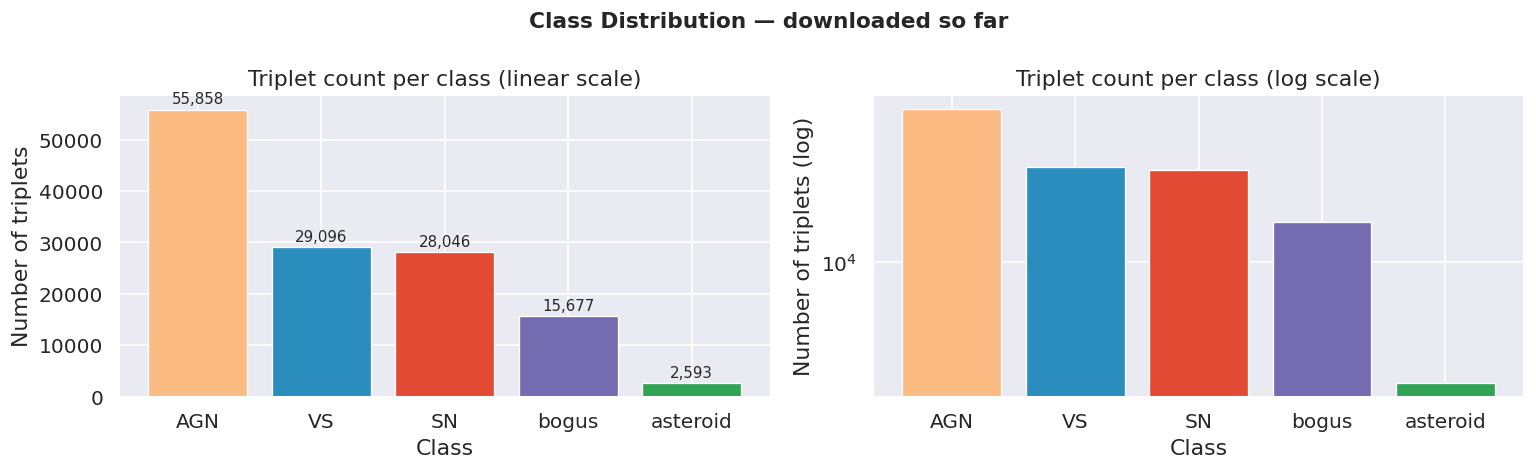


Real/Bogus split:  real=115,593  bogus=15,677
Imbalance ratio  :  0.1:1  (bogus:real)


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart — triplet counts
classes_sorted = sorted(label_counts, key=lambda c: -label_counts[c])
counts_sorted  = [label_counts[c] for c in classes_sorted]
colours_sorted = [CLASS_COLOURS.get(c, '#888') for c in classes_sorted]

axes[0].bar(classes_sorted, counts_sorted, color=colours_sorted, edgecolor='white', linewidth=0.8)
axes[0].set_title('Triplet count per class (linear scale)')
axes[0].set_ylabel('Number of triplets')
axes[0].set_xlabel('Class')
for i, (cls, n) in enumerate(zip(classes_sorted, counts_sorted)):
    axes[0].text(i, n + max(counts_sorted) * 0.01, f'{n:,}',
                 ha='center', va='bottom', fontsize=9)

# Log-scale to make minority classes visible
axes[1].bar(classes_sorted, counts_sorted, color=colours_sorted, edgecolor='white', linewidth=0.8)
axes[1].set_yscale('log')
axes[1].set_title('Triplet count per class (log scale)')
axes[1].set_ylabel('Number of triplets (log)')
axes[1].set_xlabel('Class')

plt.suptitle('Class Distribution — downloaded so far', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Real vs Bogus summary
rb = df['real_bogus'].value_counts()
print(f'\nReal/Bogus split:  real={rb.get(1,0):,}  bogus={rb.get(0,0):,}')
if rb.get(0,0):
    ratio = rb.get(0,0) / rb.get(1,0)
    print(f'Imbalance ratio  :  {ratio:.1f}:1  (bogus:real)')

## 3 — Helper utilities

In [17]:
def load_triplet(row: pd.Series) -> dict[str, np.ndarray | None]:
    """Load the science/template/difference FITS stamps for one row."""
    triplet = {}
    for key in ('science', 'template', 'difference'):
        path = PROJECT_ROOT / Path(row[f'{key}_path']).relative_to('/')
        if path.exists():
            with fits.open(path) as hdul:
                triplet[key] = hdul[0].data.copy().astype(np.float32)
        else:
            triplet[key] = None
    return triplet


def normalize_image(img: np.ndarray) -> np.ndarray:
    """Z-score normalization with NaN / Inf handling (spec §5)."""
    img = np.nan_to_num(img, nan=0.0, posinf=0.0, neginf=0.0)
    mean, std = img.mean(), img.std()
    if std == 0:
        return img - mean
    return (img - mean) / std


def plot_triplet(row: pd.Series, norm: bool = True) -> None:
    """Render the science/template/difference triplet for one detection."""
    triplet = load_triplet(row)
    fig, axes = plt.subplots(1, 3, figsize=(9, 3))
    titles = ['Science (new)', 'Template (reference)', 'Difference']
    keys   = ['science', 'template', 'difference']

    for ax, key, title in zip(axes, keys, titles):
        img = triplet[key]
        if img is None:
            ax.text(0.5, 0.5, 'MISSING', ha='center', va='center',
                    transform=ax.transAxes, color='red')
            ax.axis('off')
            continue
        display = normalize_image(img) if norm else img
        vmin, vmax = np.nanpercentile(display, [1, 99])
        ax.imshow(display, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
        ax.set_title(title, fontsize=9)
        ax.axis('off')

    cls   = row['class']
    color = CLASS_COLOURS.get(cls, 'black')
    plt.suptitle(
        f'Class: {cls}  |  OID: {row["oid"]}  |  MJD: {row["mjd"]:.3f}',
        fontsize=10, color=color, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


print('Helper functions defined.')

Helper functions defined.


## 4 — Visualise triplets — one example per available class

> **What to look for:**  
> - Real events (SN, AGN, VS, asteroid) should show a compact PSF in the science image with a matching residual in the difference.  
> - Bogus detections often show diffuse blobs, edge-of-chip artefacts, or near-zero difference images.

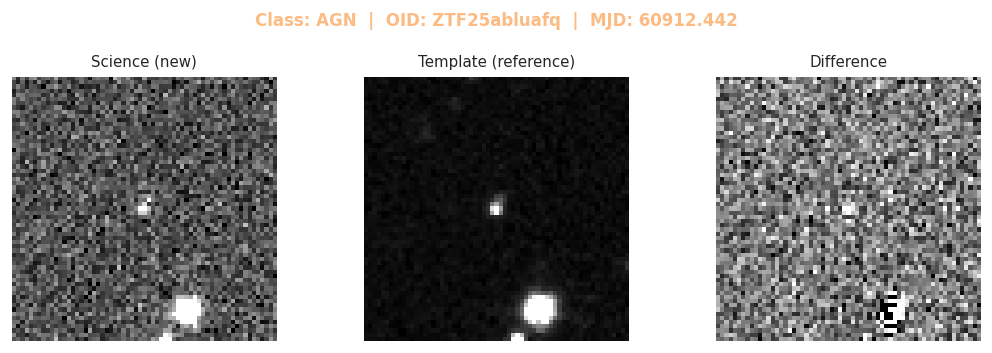

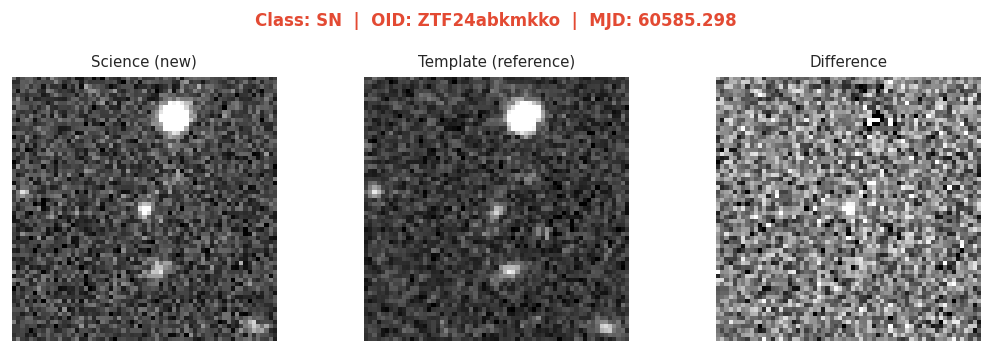

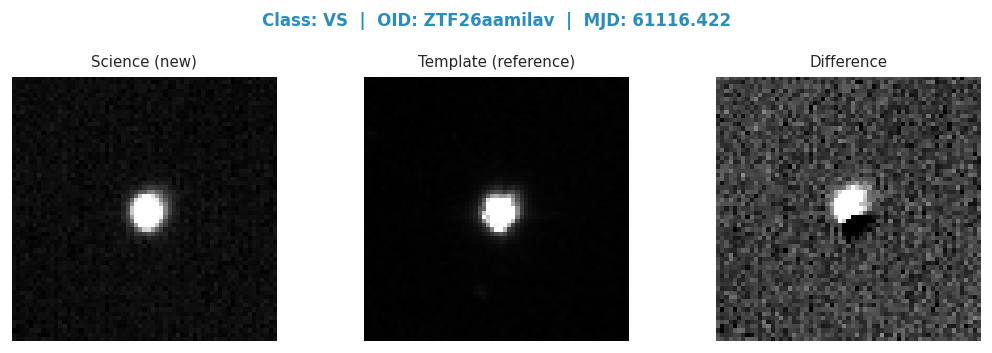

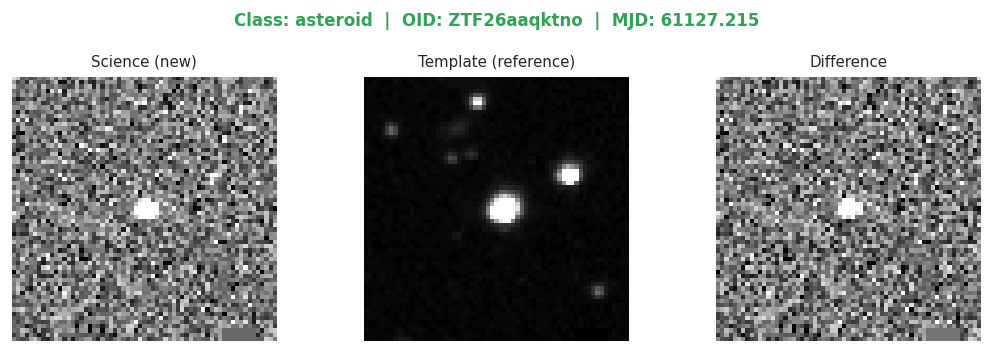

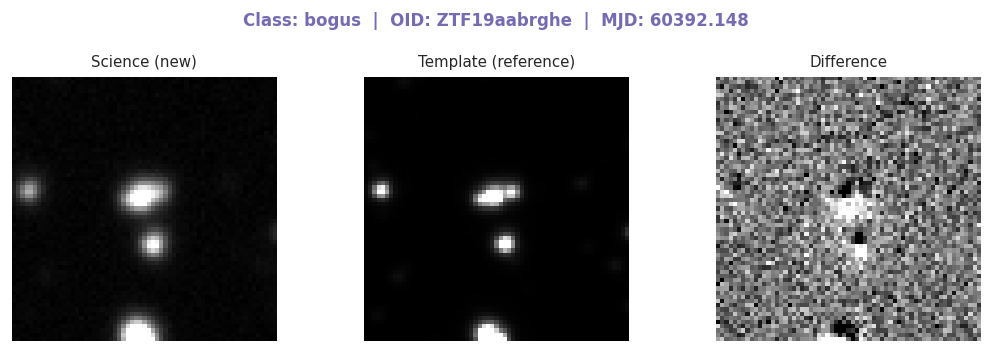

In [18]:
available_classes = df['class'].unique()

for cls in sorted(available_classes):
    subset = df[df['class'] == cls]
    # Pick the row whose stamps all exist on disk
    sample_row = None
    for _, row in subset.iterrows():
        t = load_triplet(row)
        if all(v is not None for v in t.values()):
            sample_row = row
            break
    if sample_row is None:
        print(f'[{cls}] No complete triplet found on disk — skipping.')
        continue
    plot_triplet(sample_row)

### 4b — Side-by-side comparison: real (SN) vs bogus

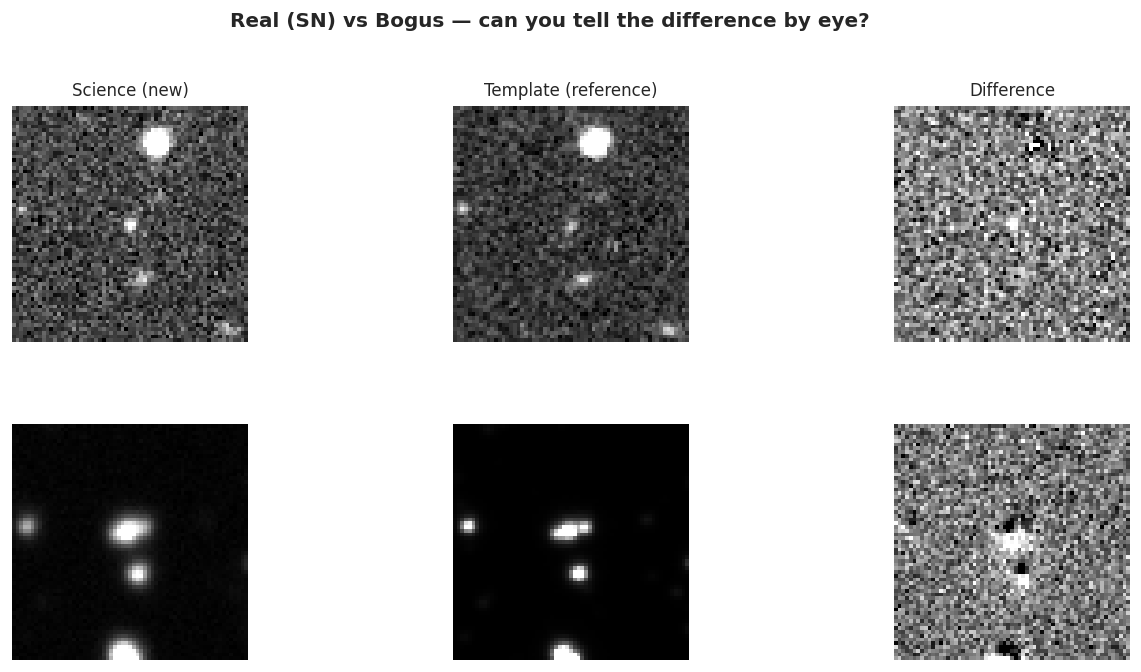

In [19]:
compare_classes = [c for c in ['SN', 'bogus'] if c in df['class'].values]

if len(compare_classes) < 2:
    print('Need both SN and bogus data for comparison. Download more classes first.')
else:
    fig = plt.figure(figsize=(14, 3 * len(compare_classes)))
    gs  = gridspec.GridSpec(len(compare_classes), 3, figure=fig, hspace=0.35, wspace=0.05)

    keys   = ['science', 'template', 'difference']
    titles = ['Science (new)', 'Template (reference)', 'Difference']

    for row_idx, cls in enumerate(compare_classes):
        subset = df[df['class'] == cls]
        for _, row in subset.iterrows():
            triplet = load_triplet(row)
            if all(v is not None for v in triplet.values()):
                break

        for col_idx, (key, title) in enumerate(zip(keys, titles)):
            ax  = fig.add_subplot(gs[row_idx, col_idx])
            img = normalize_image(triplet[key])
            vmin, vmax = np.nanpercentile(img, [1, 99])
            ax.imshow(img, cmap='gray', vmin=vmin, vmax=vmax, origin='lower')
            if row_idx == 0:
                ax.set_title(title, fontsize=10)
            if col_idx == 0:
                ax.set_ylabel(cls, fontsize=11, fontweight='bold',
                              color=CLASS_COLOURS.get(cls, 'black'), labelpad=6)
            ax.axis('off')

    plt.suptitle('Real (SN) vs Bogus — can you tell the difference by eye?',
                 fontsize=12, fontweight='bold', y=1.01)
    plt.show()

## 5 — NaN / Inf audit

Common sources: masked pixels at chip edges, saturated columns, detector defects.  
The preprocessing pipeline will zero-fill these (spec §5), but we need to know the prevalence now.

In [20]:
from tqdm.auto import tqdm

audit_records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='NaN/Inf audit'):
    for key in ('science', 'template', 'difference'):
        path = PROJECT_ROOT / Path(row[f'{key}_path']).relative_to('/')
        if not path.exists():
            continue
        with fits.open(path) as hdul:
            data = hdul[0].data.astype(np.float32)
        n_nan = int(np.sum(np.isnan(data)))
        n_inf = int(np.sum(np.isinf(data)))
        audit_records.append({
            'oid':         row['oid'],
            'candid':      row['candid'],
            'class':       row['class'],
            'stamp_type':  key,
            'n_nan':       n_nan,
            'n_inf':       n_inf,
            'pct_bad':     100 * (n_nan + n_inf) / data.size,
        })

audit_df = pd.DataFrame(audit_records)
print(f'Stamps audited : {len(audit_df):,}')

NaN/Inf audit:   0%|          | 0/131270 [00:00<?, ?it/s]

Stamps audited : 393,810


In [21]:
# Overall summary
has_bad = audit_df[(audit_df['n_nan'] > 0) | (audit_df['n_inf'] > 0)]
print(f'Stamps with any NaN/Inf : {len(has_bad):,}  '
      f'({100*len(has_bad)/len(audit_df):.1f}% of total)')
print()

# Per stamp-type
print('Mean bad-pixel % per stamp type')
print(audit_df.groupby('stamp_type')[['n_nan','n_inf','pct_bad']].mean().round(3).to_string())
print()

# Per class
print('Mean bad-pixel % per class')
print(audit_df.groupby('class')['pct_bad'].mean().round(3).to_string())

Stamps with any NaN/Inf : 43,972  (11.2% of total)

Mean bad-pixel % per stamp type
             n_nan  n_inf  pct_bad
stamp_type                        
difference  50.871    0.0    1.286
science     50.871    0.0    1.286
template    40.128    0.0    1.015

Mean bad-pixel % per class
class
AGN         0.982
SN          1.055
VS          0.785
asteroid    1.429
bogus       2.932


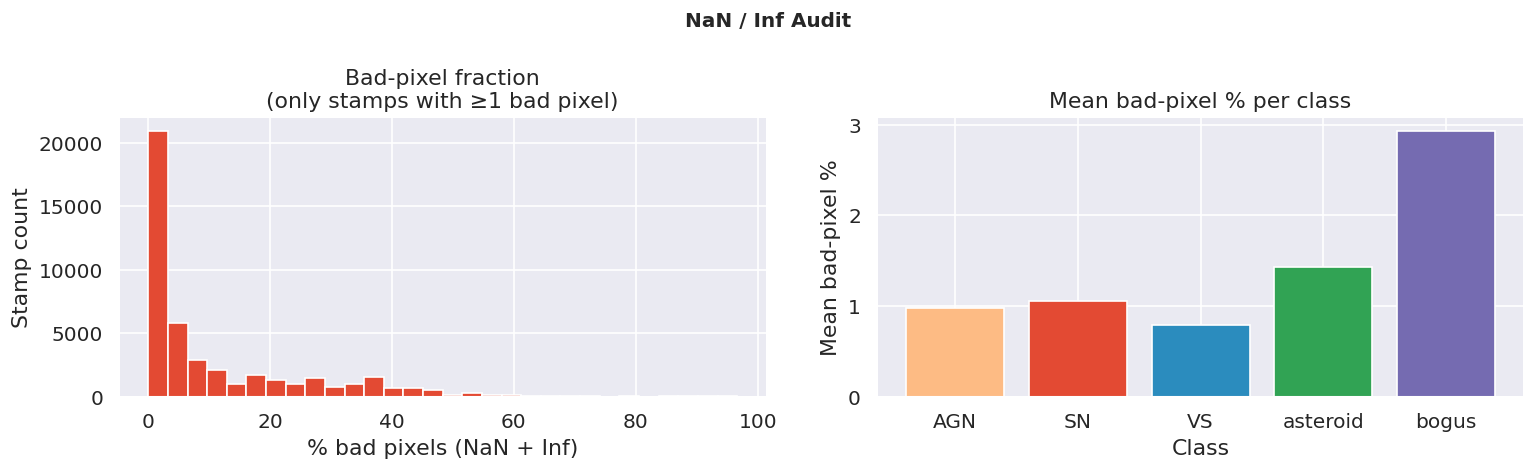

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Distribution of bad-pixel percentage
bad_nonzero = audit_df[audit_df['pct_bad'] > 0]['pct_bad']
if len(bad_nonzero) > 0:
    axes[0].hist(bad_nonzero, bins=30, color='#e34a33', edgecolor='white')
    axes[0].set_xlabel('% bad pixels (NaN + Inf)')
    axes[0].set_ylabel('Stamp count')
    axes[0].set_title('Bad-pixel fraction\n(only stamps with ≥1 bad pixel)')
else:
    axes[0].text(0.5, 0.5, 'No bad pixels found!\nData is clean.',
                 ha='center', va='center', transform=axes[0].transAxes, fontsize=12)
    axes[0].set_title('Bad-pixel fraction')

# Per class bar chart of mean pct_bad
per_class = audit_df.groupby('class')['pct_bad'].mean()
colours   = [CLASS_COLOURS.get(c,'#888') for c in per_class.index]
axes[1].bar(per_class.index, per_class.values, color=colours, edgecolor='white')
axes[1].set_xlabel('Class')
axes[1].set_ylabel('Mean bad-pixel %')
axes[1].set_title('Mean bad-pixel % per class')

plt.suptitle('NaN / Inf Audit', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 6 — Pixel value distributions per class and stamp type

Raw FITS values have wildly different scales across objects and nights.  
Understanding the distribution **before** normalisation guides the choice of preprocessing strategy.

In [23]:
# Sample up to N triplets per class for efficient statistics
N_SAMPLE = min(50, len(df))

pixel_records = []

for cls in df['class'].unique():
    subset = df[df['class'] == cls].sample(min(N_SAMPLE, len(df[df['class']==cls])),
                                           random_state=42)
    for _, row in subset.iterrows():
        for key in ('science', 'template', 'difference'):
            path = PROJECT_ROOT / Path(row[f'{key}_path']).relative_to('/')
            if not path.exists():
                continue
            with fits.open(path) as hdul:
                data = hdul[0].data.astype(np.float32)
            data = np.nan_to_num(data, nan=0., posinf=0., neginf=0.)
            pixel_records.append({
                'class':      cls,
                'stamp_type': key,
                'mean':       float(data.mean()),
                'std':        float(data.std()),
                'median':     float(np.median(data)),
                'p1':         float(np.percentile(data, 1)),
                'p99':        float(np.percentile(data, 99)),
                'min':        float(data.min()),
                'max':        float(data.max()),
            })

pixel_df = pd.DataFrame(pixel_records)
print(f'Records collected: {len(pixel_df):,}')
pixel_df.groupby(['class','stamp_type'])[['mean','std','median']].mean().round(2)

Records collected: 750


mean     std  median
class    stamp_type                        
AGN      difference    0.20   10.23    0.07
         science     177.67   45.36  175.25
         template    177.58   38.52  175.11
SN       difference    1.53   30.56    0.19
         science     201.02  100.36  190.77
         template    199.67   87.53  190.11
VS       difference    1.81  102.96   -3.88
         science     151.25  387.85  123.91
         template    142.39  326.63  118.74
asteroid difference    1.60   47.32    0.17
         science     195.26  160.53  189.14
         template    193.74  106.38  188.53
bogus    difference    1.95   20.88    1.38
         science     261.42  171.18  242.55
         template      -inf     inf  240.43

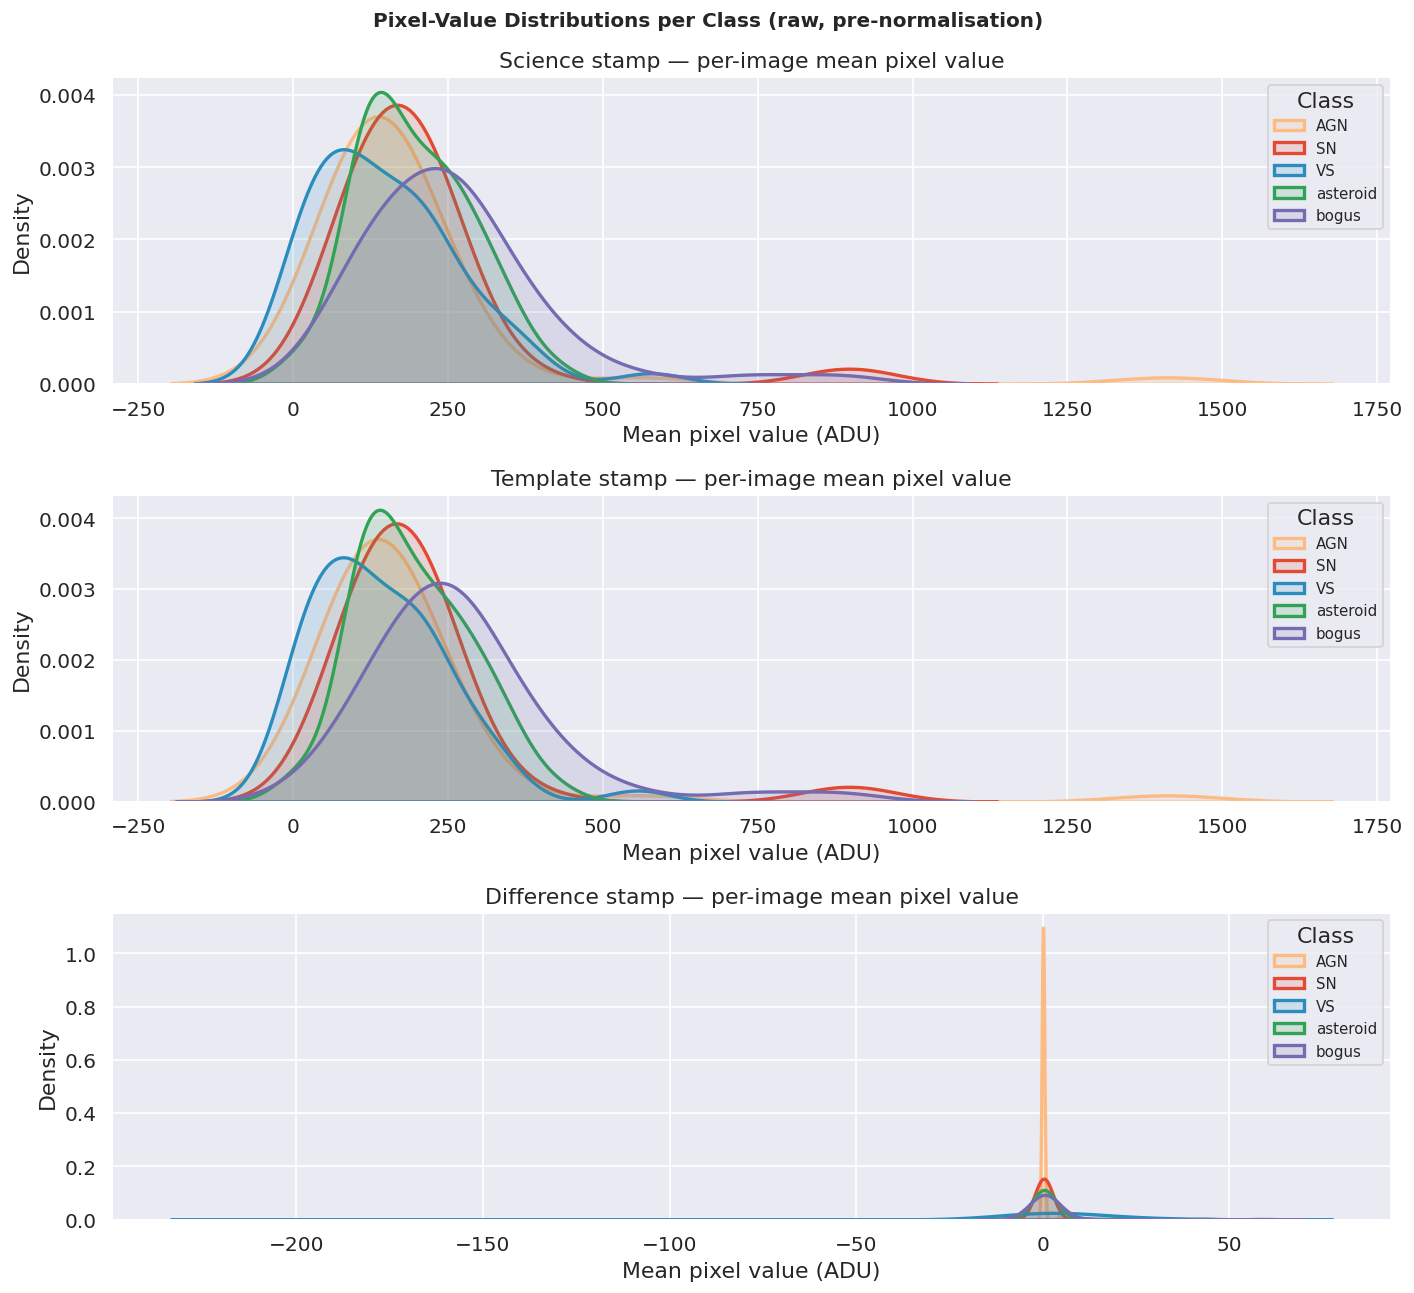

In [24]:
stamp_types = ['science', 'template', 'difference']
available_cls = sorted(df['class'].unique())

fig, axes = plt.subplots(3, 1, figsize=(12, 11), sharex=False)

for ax, stype in zip(axes, stamp_types):
    sub = pixel_df[pixel_df['stamp_type'] == stype]
    for cls in available_cls:
        vals = sub[sub['class'] == cls]['mean']
        if len(vals) == 0:
            continue
        sns.kdeplot(
            vals, ax=ax, label=cls,
            color=CLASS_COLOURS.get(cls, '#888'),
            linewidth=2, fill=True, alpha=0.15
        )
    ax.set_title(f'{stype.capitalize()} stamp — per-image mean pixel value')
    ax.set_xlabel('Mean pixel value (ADU)')
    ax.set_ylabel('Density')
    ax.legend(title='Class', fontsize=9)

plt.suptitle('Pixel-Value Distributions per Class (raw, pre-normalisation)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

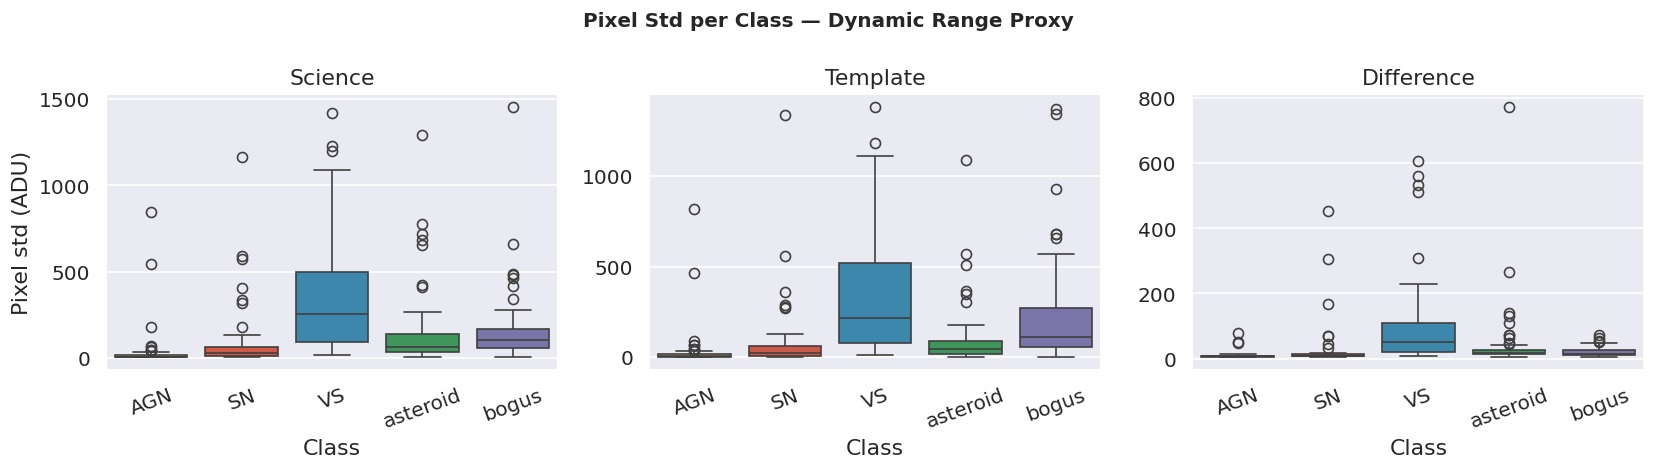

In [25]:
# Per-class box plot of pixel std — proxy for image "dynamic range"
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=False)

for ax, stype in zip(axes, stamp_types):
    sub = pixel_df[pixel_df['stamp_type'] == stype]
    order = sorted(sub['class'].unique())
    palette = {c: CLASS_COLOURS.get(c,'#888') for c in order}
    sns.boxplot(
        data=sub, x='class', y='std', order=order,
        palette=palette, ax=ax, linewidth=1
    )
    ax.set_title(f'{stype.capitalize()}')
    ax.set_xlabel('Class')
    ax.set_ylabel('Pixel std (ADU)' if stype == 'science' else '')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Pixel Std per Class — Dynamic Range Proxy',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

## 7 — Image quality consistency across nights

ZTF observations span multiple nights and sky conditions.  
We use the per-image pixel std of the science stamp as a rough "background noise" proxy.

In [26]:
# Merge per-stamp statistics back onto the main df using candid
sci_stats = pixel_df[pixel_df['stamp_type'] == 'science'][['class','mean','std']].copy()

# Recompute with MJD so we can plot over time
time_records = []
for _, row in tqdm(df.iterrows(), total=len(df), desc='Quality over time'):
    path = PROJECT_ROOT / row['science_path'].lstrip('/')
    if not path.exists():
        continue
    with fits.open(path) as hdul:
        data = hdul[0].data.astype(np.float32)
    data = np.nan_to_num(data, nan=0., posinf=0., neginf=0.)
    time_records.append({
        'mjd':   row['mjd'],
        'class': row['class'],
        'std':   float(data.std()),
        'mean':  float(data.mean()),
    })

time_df = pd.DataFrame(time_records).sort_values('mjd')
print(f'Observations: {len(time_df):,}  '
      f'MJD range: {time_df["mjd"].min():.1f} – {time_df["mjd"].max():.1f}')

Quality over time:   0%|          | 0/131270 [00:00<?, ?it/s]

Observations: 131,270  MJD range: 58270.4 – 61128.3


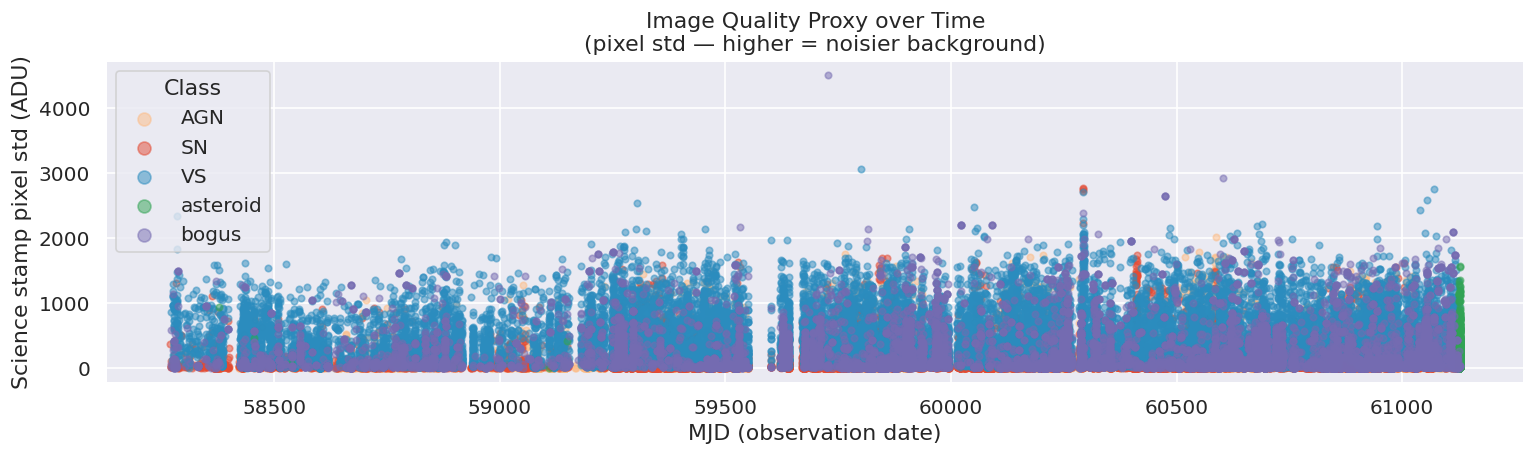

In [27]:
if len(df['class'].unique()) > 1 and time_df['mjd'].nunique() > 3:
    fig, ax = plt.subplots(figsize=(13, 4))
    for cls in sorted(time_df['class'].unique()):
        sub = time_df[time_df['class'] == cls]
        ax.scatter(sub['mjd'], sub['std'], s=15, alpha=0.5,
                   label=cls, color=CLASS_COLOURS.get(cls,'#888'))
    ax.set_xlabel('MJD (observation date)')
    ax.set_ylabel('Science stamp pixel std (ADU)')
    ax.set_title('Image Quality Proxy over Time\n(pixel std — higher = noisier background)')
    ax.legend(title='Class', markerscale=2)
    plt.tight_layout()
    plt.show()
else:
    fig, ax = plt.subplots(figsize=(12, 4))
    for cls in sorted(time_df['class'].unique()):
        sub = time_df[time_df['class'] == cls]
        ax.scatter(sub['mjd'], sub['std'], s=20, alpha=0.6,
                   label=cls, color=CLASS_COLOURS.get(cls,'#888'))
    ax.set_xlabel('MJD')
    ax.set_ylabel('Science stamp pixel std')
    ax.set_title('Image Quality over Time (limited data)')
    ax.legend(title='Class')
    plt.tight_layout()
    plt.show()

## 8 — Temporal coverage

We need to understand the MJD range of the dataset to plan the **time-based train/val/test split** (spec §5).  
Training on the past and testing on the future prevents data leakage.

In [28]:
print('MJD range of downloaded data')
print('=' * 45)
for cls in sorted(df['class'].unique()):
    sub = df[df['class'] == cls]
    print(f'  {cls:10s}: {sub["mjd"].min():.2f} → {sub["mjd"].max():.2f}  '
          f'(span {sub["mjd"].max()-sub["mjd"].min():.0f} days)')

print()
print('Proposed time-based split:')
mjd_all = df['mjd'].sort_values()
n = len(mjd_all)
train_end = mjd_all.iloc[int(0.70 * n)]
val_end   = mjd_all.iloc[int(0.85 * n)]
print(f'  Train : MJD ≤ {train_end:.2f}   ({int(0.70*n):,} triplets, 70%)')
print(f'  Val   : {train_end:.2f} < MJD ≤ {val_end:.2f}  ({int(0.15*n):,} triplets, 15%)')
print(f'  Test  : MJD > {val_end:.2f}   ({n - int(0.85*n):,} triplets, 15%)')

MJD range of downloaded data
  AGN       : 58280.21 → 61126.42  (span 2846 days)
  SN        : 58270.40 → 61126.53  (span 2856 days)
  VS        : 58272.26 → 61126.54  (span 2854 days)
  asteroid  : 58378.49 → 61128.26  (span 2750 days)
  bogus     : 58272.26 → 61127.15  (span 2855 days)

Proposed time-based split:
  Train : MJD ≤ 60635.11   (91,889 triplets, 70%)
  Val   : 60635.11 < MJD ≤ 60918.33  (19,690 triplets, 15%)
  Test  : MJD > 60918.33   (19,691 triplets, 15%)


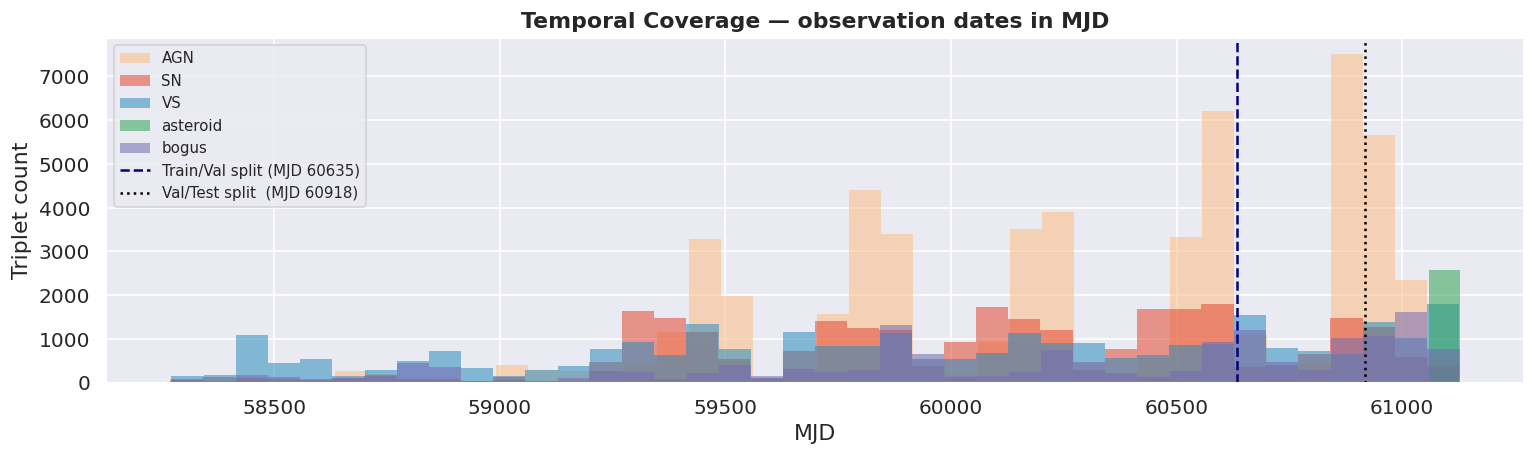

In [29]:
fig, ax = plt.subplots(figsize=(13, 4))

for cls in sorted(df['class'].unique()):
    sub = df[df['class'] == cls]['mjd']
    ax.hist(sub, bins=40, alpha=0.55,
            label=cls, color=CLASS_COLOURS.get(cls, '#888'),
            edgecolor='none')

# Mark split boundaries
ax.axvline(train_end, color='navy',  linestyle='--', linewidth=1.5, label=f'Train/Val split (MJD {train_end:.0f})')
ax.axvline(val_end,   color='black', linestyle=':',  linewidth=1.5, label=f'Val/Test split  (MJD {val_end:.0f})')

ax.set_xlabel('MJD')
ax.set_ylabel('Triplet count')
ax.set_title('Temporal Coverage — observation dates in MJD', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

## 9 — Artefact inspection

We flag potentially artefactual stamps using three heuristics:

| Heuristic | What it catches |
|---|---|
| **Near-zero variance** | Flat / blank stamps (readout failure) |
| **Extreme max/min ratio** | Saturated pixels, cosmic rays, satellite trails |
| **High bad-pixel fraction** | Chip gaps, masked regions |

These are not automatically removed — they are flagged for manual review.

In [30]:
flag_records = []

for _, row in tqdm(df.iterrows(), total=len(df), desc='Artefact flag'):
    flags = []
    for key in ('science', 'template', 'difference'):
        path = PROJECT_ROOT / row['science_path'].lstrip('/')
        if not path.exists():
            flags.append(f'{key}:MISSING')
            continue
        with fits.open(path) as hdul:
            data = hdul[0].data.astype(np.float32)
        clean = np.nan_to_num(data, nan=0., posinf=0., neginf=0.)
        pct_bad = 100 * (np.sum(np.isnan(data)) + np.sum(np.isinf(data))) / data.size

        if clean.std() < 1e-6:
            flags.append(f'{key}:FLAT')
        if data.max() > 1e6:            # saturated
            flags.append(f'{key}:SATURATED')
        if pct_bad > 10:
            flags.append(f'{key}:BADPIX>{pct_bad:.0f}%')

    flag_records.append({
        'oid':    row['oid'],
        'candid': row['candid'],
        'class':  row['class'],
        'flags':  '; '.join(flags) if flags else '',
        'n_flags': len(flags),
    })

flag_df = pd.DataFrame(flag_records)
flagged  = flag_df[flag_df['n_flags'] > 0]

print(f'Flagged triplets: {len(flagged):,} / {len(flag_df):,}  '
      f'({100*len(flagged)/len(flag_df):.1f}%)')
if len(flagged) > 0:
    print()
    print(flagged[['oid','candid','class','flags']].head(10).to_string(index=False))

Artefact flag:   0%|          | 0/131270 [00:00<?, ?it/s]

Flagged triplets: 5,035 / 131,270  (3.8%)

         oid              candid class                                                          flags
ZTF22absuknq 2134186003715010006 bogus science:BADPIX>54%; template:BADPIX>54%; difference:BADPIX>54%
ZTF24abzpdnt 2918187683315010002 bogus science:BADPIX>70%; template:BADPIX>70%; difference:BADPIX>70%
ZTF22abiaehs 2093264211315010002 bogus science:BADPIX>10%; template:BADPIX>10%; difference:BADPIX>10%
ZTF22abudshx 2145345301215015029 bogus science:BADPIX>29%; template:BADPIX>29%; difference:BADPIX>29%
ZTF25acfwveu 3260251865715010000 bogus science:BADPIX>62%; template:BADPIX>62%; difference:BADPIX>62%
ZTF18acwrmry  713408542715015037 bogus science:BADPIX>13%; template:BADPIX>13%; difference:BADPIX>13%
ZTF21accwpje 1720442490015010005 bogus science:BADPIX>57%; template:BADPIX>57%; difference:BADPIX>57%
ZTF21accwpje 2181315470015010003 bogus science:BADPIX>55%; template:BADPIX>55%; difference:BADPIX>55%
ZTF22abuvvmt 2147397971315010006 bogus 

Worst flagged stamp: science:BADPIX>34%; template:BADPIX>34%; difference:BADPIX>34%


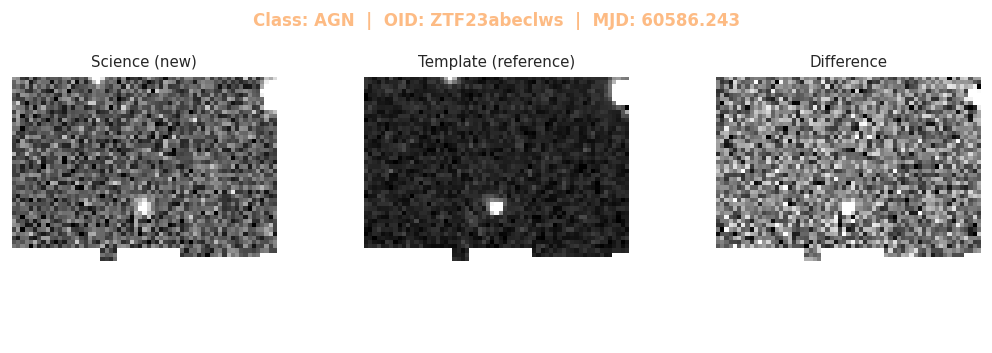

In [31]:
if len(flagged) > 0:
    # Show one flagged triplet if any exist
    worst_row = flag_df.sort_values('n_flags', ascending=False).iloc[0]
    match = df[(df['oid'] == worst_row['oid']) & (df['candid'] == worst_row['candid'])]
    if len(match) > 0:
        print(f'Worst flagged stamp: {worst_row["flags"]}')
        plot_triplet(match.iloc[0], norm=False)   # show raw values to reveal artefact
    else:
        print('Flagged row not found in df (candid mismatch).')
else:
    print('No artefacts flagged in the current dataset.')

## 10 — Detections per object

Each ZTF object can have many detections across multiple nights.  
Understanding this helps decide whether to sample one detection per object or use all of them.

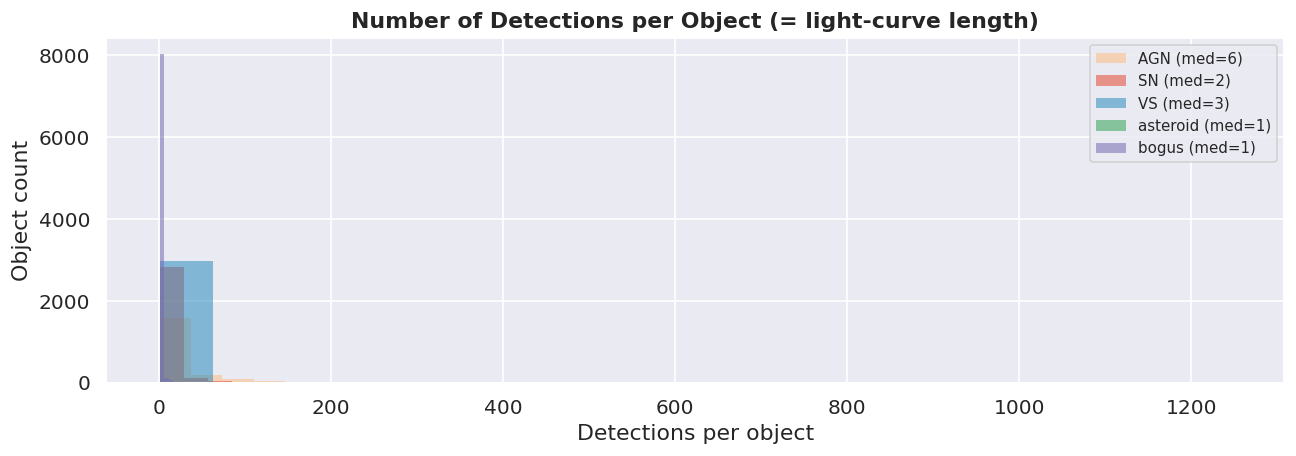

          min  mean  50%     max
class                           
AGN       1.0  28.6  6.0   731.0
SN        1.0   9.4  2.0   566.0
VS        1.0   9.7  3.0  1246.0
asteroid  1.0   1.0  1.0     3.0
bogus     1.0   1.9  1.0   108.0


In [32]:
dets_per_object = df.groupby(['class','oid']).size().reset_index(name='n_detections')

fig, ax = plt.subplots(figsize=(11, 4))
for cls in sorted(dets_per_object['class'].unique()):
    sub = dets_per_object[dets_per_object['class'] == cls]['n_detections']
    ax.hist(sub, bins=20, alpha=0.55,
            label=f'{cls} (med={sub.median():.0f})',
            color=CLASS_COLOURS.get(cls,'#888'), edgecolor='none')

ax.set_xlabel('Detections per object')
ax.set_ylabel('Object count')
ax.set_title('Number of Detections per Object (= light-curve length)', fontweight='bold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(dets_per_object.groupby('class')['n_detections']
      .describe()[['min','mean','50%','max']].round(1).to_string())

## 11 — Normalisation preview

Compare raw vs Z-score normalised pixel distributions for a handful of stamps.  
This validates that the preprocessing in spec §5 is appropriate.

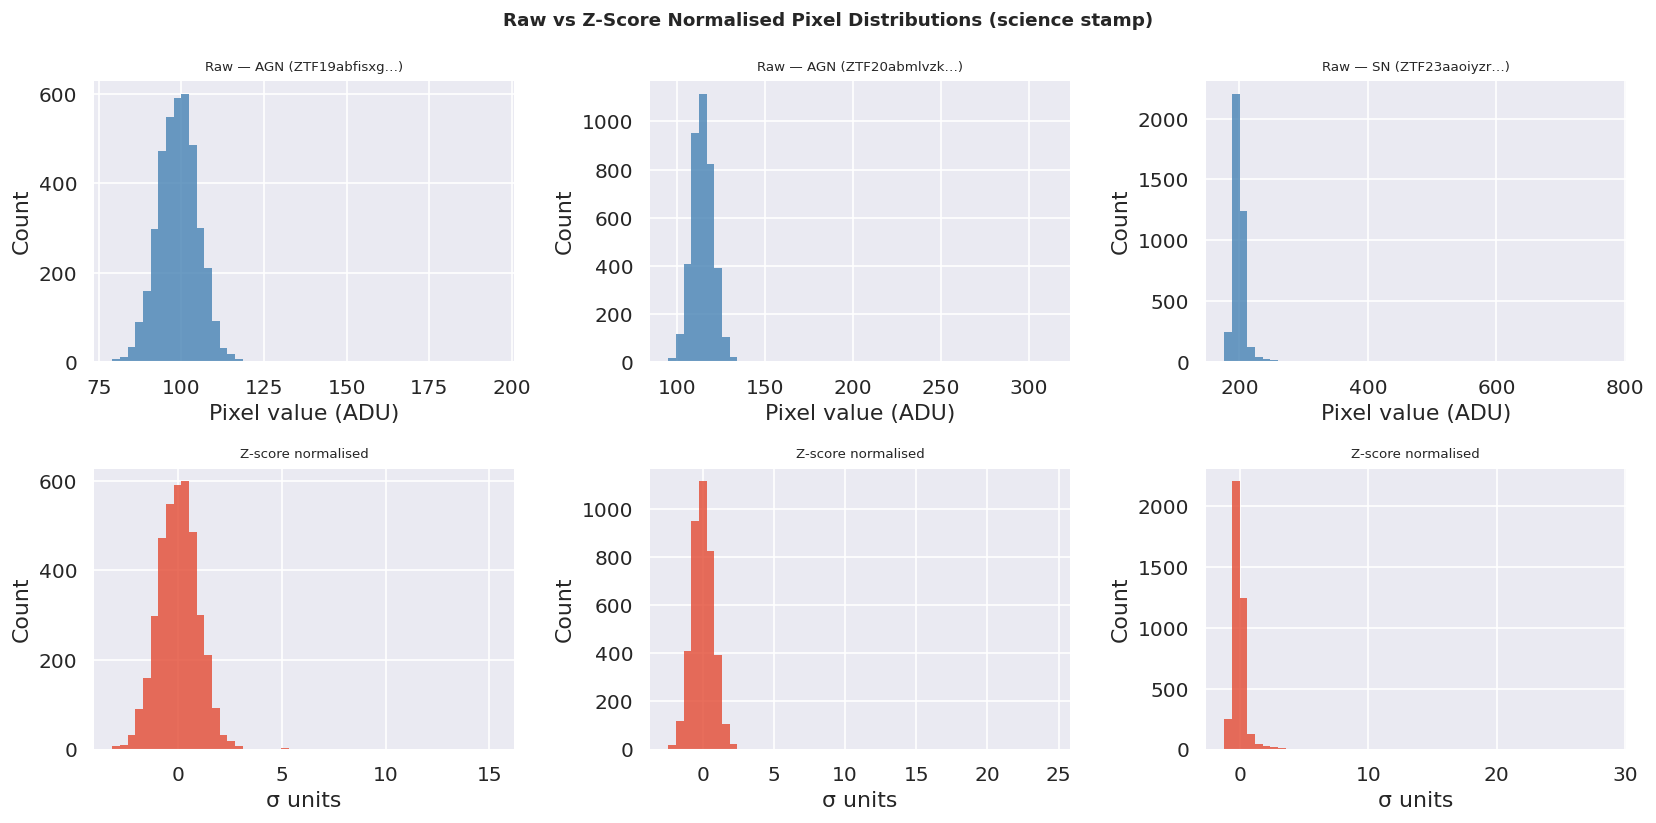

In [33]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))

sample_rows = df.sample(min(3, len(df)), random_state=0)

for col_idx, (_, row) in enumerate(sample_rows.iterrows()):
    path = PROJECT_ROOT / row['science_path'].lstrip('/')
    if not path.exists():
        continue
    with fits.open(path) as hdul:
        raw = hdul[0].data.astype(np.float32)
    normed = normalize_image(raw)

    axes[0, col_idx].hist(raw.ravel(), bins=50,
                          color='steelblue', edgecolor='none', alpha=0.8)
    axes[0, col_idx].set_title(f'Raw — {row["class"]} ({row["oid"][:14]}…)', fontsize=8)
    axes[0, col_idx].set_xlabel('Pixel value (ADU)')

    axes[1, col_idx].hist(normed.ravel(), bins=50,
                          color='#e34a33', edgecolor='none', alpha=0.8)
    axes[1, col_idx].set_title('Z-score normalised', fontsize=8)
    axes[1, col_idx].set_xlabel('σ units')

for ax in axes.ravel():
    ax.set_ylabel('Count')

plt.suptitle('Raw vs Z-Score Normalised Pixel Distributions (science stamp)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 12 — Summary & key findings

In [34]:
rb = df['real_bogus'].value_counts()
real_n  = rb.get(1, 0)
bogus_n = rb.get(0, 0)

print('=' * 60)
print('DATA EXPLORATION — KEY FINDINGS')
print('=' * 60)

print(f'\n[Dataset]')
print(f'  Total triplets downloaded : {len(df):,}')
print(f'  Unique objects            : {df["oid"].nunique():,}')
print(f'  Classes present           : {sorted(df["class"].unique())}')
print(f'  Real : Bogus              : {real_n:,} : {bogus_n:,}', end='')
if bogus_n and real_n:
    print(f'  ({bogus_n/real_n:.1f}:1 imbalance)')
else:
    print()

print(f'\n[NaN / Inf]')
bad_pct = 100 * len(has_bad) / len(audit_df) if len(audit_df) else 0
print(f'  Stamps with bad pixels    : {len(has_bad):,}  ({bad_pct:.1f}%)')
print(f'  Action: zero-fill via np.nan_to_num() in preprocessing (spec §5)')

print(f'\n[Pixel values]')
print(f'  Science median pixel std  : {pixel_df[pixel_df["stamp_type"]=="science"]["std"].median():.1f} ADU')
print(f'  Difference images centre near zero — as expected for subtractions')

print(f'\n[Artefacts]')
print(f'  Flagged triplets          : {len(flagged):,}  ({100*len(flagged)/max(len(flag_df),1):.1f}%)')

print(f'\n[Temporal]')
print(f'  MJD range                 : {df["mjd"].min():.1f} → {df["mjd"].max():.1f}')
print(f'  Time-based split will be used: 70/15/15 train/val/test (no shuffling)')

print(f'\n[Next steps]')
print(f'  Open 02_preprocessing.ipynb to build the dataset pipeline')
print('=' * 60)

DATA EXPLORATION — KEY FINDINGS

[Dataset]
  Total triplets downloaded : 131,270
  Unique objects            : 18,682
  Classes present           : ['AGN', 'SN', 'VS', 'asteroid', 'bogus']
  Real : Bogus              : 115,593 : 15,677  (0.1:1 imbalance)

[NaN / Inf]
  Stamps with bad pixels    : 43,972  (11.2%)
  Action: zero-fill via np.nan_to_num() in preprocessing (spec §5)

[Pixel values]
  Science median pixel std  : 58.3 ADU
  Difference images centre near zero — as expected for subtractions

[Artefacts]
  Flagged triplets          : 5,035  (3.8%)

[Temporal]
  MJD range                 : 58270.4 → 61128.3
  Time-based split will be used: 70/15/15 train/val/test (no shuffling)

[Next steps]
  Open 02_preprocessing.ipynb to build the dataset pipeline
